# Proyek Analisis data rekomendasi pekerjaan berdasarkan skill yang dimiliki

## Menentukan Pertanyaan Bisnis

- Skill apa saja yang paling sering dicari untuk posisi pekerjaan tertentu?
- Bagaimana distribusi gaji berdasarkan industri?

## Import Semua Packages/Library yang Digunakan

In [ ]:
# Import library yang dibutuhkan untuk analisis data dan visualisasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

Bagian ini berfokus pada pengumpulan data dari berbagai sumber. Dalam proyek ini, kita akan memuat dua dataset berbeda yang berisi informasi lowongan pekerjaan.

In [ ]:
# Memuat dataset pertama dari file CSV 'job_market.csv'
# Dataset ini berisi informasi lowongan pekerjaan dari satu sumber
job1_df = pd.read_csv('job_market.csv')
# Menampilkan 5 baris pertama dari job1_df untuk melihat struktur data
job1_df.head()

,job_title,company,location,job_type,category,salary_min,salary_max,experience_required,publication_date,skills,education_level,company_size,benefits
0,Engineering Manager,DataInc,"San Francisco, CA",Remote,Technology,151082,291345,4.0,11/27/2025,"AWS, Agile, Machine Learning, Kubernetes, Mong...",Master's Degree,1-50 employees,"Health Insurance, 401(k), Unlimited PTO"
1,Engineering Manager,EnterpriseHub,"New York, NY",Remote,Technology,156891,280075,3.0,11/27/2025,"Java, Agile, Git, SQL, Ruby, Go",PhD,1-50 employees,"Dental, Vision, Annual Bonus"
2,Engineering Manager,StartupXYZ,"Seattle, WA",Part-time,Technology,152134,280310,4.0,11/27/2025,"AWS, Python, Kubernetes, Git",Associate Degree,1000+ employees,"Stock Options, Remote Work Stipend"
3,Lead Engineer,WebDynamics,"Seattle, WA",Full-time,Technology,151918,253988,7.0,11/27/2025,"Agile, Git, Docker, REST APIs, TypeScript",PhD,1000+ employees,"Health Insurance, 401(k), Unlimited PTO"
4,Senior Software Engineer,DigitalWorks,"San Francisco, CA",Full-time,Technology,148141,252584,9.0,11/27/2025,"Agile, Ruby, Docker, Git, JavaScript",High School,1000+ employees,"Health Insurance, 401(k), Unlimited PTO"


In [ ]:
# Memuat dataset kedua dari file CSV 'job_recommendation_dataset.csv'
# Dataset ini berisi informasi lowongan pekerjaan dari sumber lain
job2_df = pd.read_csv('job_recommendation_dataset.csv')
# Menampilkan 5 baris pertama dari job2_df untuk melihat struktur data
job2_df.head()

,Job Title,Company,Location,Experience Level,Salary,Industry,Required Skills
0,Early years teacher,Richardson Ltd,Sydney,Senior Level,87000.0,Healthcare,Pharmaceuticals
1,Counselling psychologist,"Ramos, Santiago and Stewart",San Francisco,Mid Level,50000.0,Marketing,"Google Ads, SEO, Content Writing"
2,Radio broadcast assistant,Franco Group,New York,Mid Level,77000.0,Healthcare,"Patient Care, Nursing, Medical Research, Pharm..."
3,"Designer, exhibition/display",Collins Inc,Berlin,Senior Level,90000.0,Software,Machine Learning
4,"Psychotherapist, dance movement",Barker Group,Sydney,Entry Level,112000.0,Healthcare,"Nursing, Medical Research, Pharmaceuticals"


#### Insight:
- Dua dataset, `job_market.csv` (job1_df) dan `job_recommendation_dataset.csv` (job2_df), telah berhasil dimuat.
- `job1_df` memiliki informasi lowongan pekerjaan yang lebih detail termasuk rentang gaji, tingkat pengalaman, tingkat pendidikan, dan daftar skill.
- `job2_df` memiliki jumlah baris yang jauh lebih banyak dan fokus pada judul pekerjaan, perusahaan, lokasi, tingkat pengalaman, gaji tunggal, industri, dan skill yang dibutuhkan.
- Ada beberapa kolom yang tumpang tindih namun juga kolom unik di antara kedua dataset, yang mengindikasikan perlunya proses pembersihan dan penggabungan untuk analisis komprehensif.

### Assessing Data

Setelah data terkumpul, langkah selanjutnya adalah melakukan penilaian awal untuk memahami karakteristik data. Ini melibatkan pemeriksaan tipe data, identifikasi nilai yang hilang (missing values), pengecekan duplikasi data, dan melihat ringkasan statistik dasar untuk setiap dataset.

In [ ]:
# Menampilkan informasi ringkas tentang DataFrame job1_df
# Ini termasuk jumlah entri, jumlah kolom, tipe data setiap kolom, dan penggunaan memori
job1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_title            250 non-null    object 
 1   company              250 non-null    object 
 2   location             250 non-null    object 
 3   job_type             221 non-null    object 
 4   category             230 non-null    object 
 5   salary_min           250 non-null    int64  
 6   salary_max           250 non-null    int64  
 7   experience_required  207 non-null    float64
 8   publication_date     250 non-null    object 
 9   skills               200 non-null    object 
 10  education_level      250 non-null    object 
 11  company_size         250 non-null    object 
 12  benefits             250 non-null    object 
dtypes: float64(1), int64(2), object(10)
memory usage: 25.5+ KB


In [ ]:
# Menghitung jumlah nilai yang hilang (NaN) di setiap kolom pada job1_df
# Ini membantu mengidentifikasi kolom mana yang memerlukan penanganan missing value
job1_df.isna().sum()

,0
job_title,0
company,0
location,0
job_type,29
category,20
salary_min,0
salary_max,0
experience_required,43
publication_date,0
skills,50


In [ ]:
# Memeriksa jumlah baris duplikat dalam job1_df
# Duplikasi dapat mempengaruhi analisis dan perlu ditangani jika ada
print("Jumlah duplikasi: ", job1_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
# Menampilkan statistik deskriptif untuk kolom numerik dalam job1_df
# Ini memberikan ringkasan seperti mean, median, min, max, dan standar deviasi
job1_df.describe()

,salary_min,salary_max,experience_required
count,250.000000,250.000000,207.000000
mean,89067.900000,155685.424000,4.227053
std,23183.593666,42842.170809,2.461676
min,45000.000000,70000.000000,0.000000
25%,71880.500000,130631.750000,2.500000
50%,88136.000000,149535.000000,4.000000
75%,105755.250000,186913.500000,5.000000
max,156891.000000,291345.000000,12.000000


In [ ]:
# Menampilkan informasi ringkas tentang DataFrame job2_df
# Ini termasuk jumlah entri, jumlah kolom, tipe data setiap kolom, dan penggunaan memori
job2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Job Title         50000 non-null  object 
 1   Company           50000 non-null  object 
 2   Location          50000 non-null  object 
 3   Experience Level  50000 non-null  object 
 4   Salary            50000 non-null  float64
 5   Industry          50000 non-null  object 
 6   Required Skills   50000 non-null  object 
dtypes: float64(1), object(6)
memory usage: 2.7+ MB


In [ ]:
# Menghitung jumlah nilai yang hilang (NaN) di setiap kolom pada job2_df
# Ini membantu mengidentifikasi kolom mana yang memerlukan penanganan missing value
job2_df.isna().sum()

,0
Job Title,0
Company,0
Location,0
Experience Level,0
Salary,0
Industry,0
Required Skills,0


In [ ]:
# Memeriksa jumlah baris duplikat dalam job2_df
# Duplikasi dapat mempengaruhi analisis dan perlu ditangani jika ada
print("Jumlah duplikasi: ", job2_df.duplicated().sum())

Jumlah duplikasi:  0


In [ ]:
# Menampilkan statistik deskriptif untuk kolom numerik dalam job2_df
# Ini memberikan ringkasan seperti mean, median, min, max, dan standar deviasi
job2_df.describe()

,Salary
count,50000.000000
mean,95145.100000
std,31782.635648
min,40000.000000
25%,68000.000000
50%,95000.000000
75%,123000.000000
max,150000.000000


#### Insight:
- **job1_df:** Ditemukan nilai yang hilang di kolom `job_type`, `category`, `experience_required`, dan `skills`. Tidak ada duplikasi data. Kolom numerik seperti `salary_min`, `salary_max`, dan `experience_required` menunjukkan rentang nilai yang bervariasi, dengan `experience_required` memiliki nilai maksimum yang cukup tinggi (12 tahun) dan rata-rata 4.2 tahun.
- **job2_df:** Tidak ditemukan nilai yang hilang maupun duplikasi data. Semua kolom memiliki tipe data yang sesuai, kecuali `Experience Level`, `Industry`, dan `Location` yang akan lebih efisien jika diubah menjadi kategori.

### Cleaning Data

Bagian ini didedikasikan untuk membersihkan dan menyiapkan data. Proses cleaning mencakup penanganan nilai yang hilang, koreksi tipe data yang tidak sesuai, serta penanganan outlier atau inkonsistensi yang ditemukan selama tahap penilaian data. Tujuan utamanya adalah memastikan data siap untuk analisis lebih lanjut.

In [ ]:
# Menghitung ulang jumlah nilai yang hilang (NaN) di setiap kolom pada job1_df setelah proses pengumpulan data
job1_df.isna().sum()

,0
job_title,0
company,0
location,0
job_type,29
category,20
salary_min,0
salary_max,0
experience_required,43
publication_date,0
skills,50


In [ ]:
# Menghapus baris-baris dari job1_df di mana kolom 'skills' memiliki nilai yang hilang (NaN)
# Kolom 'skills' sangat krusial untuk rekomendasi pekerjaan, sehingga baris tanpa skill dihapus
job1_df.dropna(subset=['skills'], inplace=True)

In [ ]:
# Mengisi nilai yang hilang (NaN) di kolom 'experience_required' dengan nilai median dari kolom tersebut
# Menggunakan median lebih robust terhadap outlier dibandingkan mean
job1_df['experience_required'] = job1_df['experience_required'].fillna(job1_df['experience_required'].median())

In [ ]:
# Mengisi nilai yang hilang (NaN) di kolom 'category' dengan string "Unknown"
# Ini memungkinkan kita untuk tetap mempertahankan baris tersebut dan mengidentifikasi kategori yang tidak spesifik
job1_df['category'] = job1_df['category'].fillna("Unknown")

In [ ]:
# Memeriksa kembali jumlah nilai yang hilang di job1_df setelah penanganan missing value
# Harusnya semua kolom yang ditangani sudah tidak memiliki nilai hilang
job1_df.isna().sum()

,0
job_title,0
company,0
location,0
job_type,0
category,0
salary_min,0
salary_max,0
experience_required,0
publication_date,0
skills,0


In [ ]:
# Menampilkan statistik deskriptif untuk job1_df setelah proses cleaning data
# Ini membantu melihat perubahan distribusi setelah penanganan missing value dan outlier
job1_df.describe()

,salary_min,salary_max,experience_required
count,200.000000,200.000000,200.00000
mean,92809.875000,162806.780000,4.20000
std,22348.923046,40703.964781,2.46992
min,50892.000000,90437.000000,0.00000
25%,75988.750000,136103.500000,2.75000
50%,89114.000000,151501.000000,4.00000
75%,107534.750000,190733.500000,5.00000
max,156891.000000,291345.000000,12.00000


In [ ]:
# Memperbaiki nilai yang tidak wajar pada kolom 'experience_required'
# Nilai pengalaman > 20 tahun dianggap tidak realistis dan diganti dengan median dari kolom tersebut
job1_df.loc[job1_df['experience_required'] > 20, 'experience_required'] = job1_df['experience_required'].median()

In [ ]:
# Menampilkan informasi ringkas tentang DataFrame job2_df setelah proses gathering data
# Ini membantu melihat struktur dan tipe data sebelum cleaning
job2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Job Title         50000 non-null  object 
 1   Company           50000 non-null  object 
 2   Location          50000 non-null  object 
 3   Experience Level  50000 non-null  object 
 4   Salary            50000 non-null  float64
 5   Industry          50000 non-null  object 
 6   Required Skills   50000 non-null  object 
dtypes: float64(1), object(6)
memory usage: 2.7+ MB


In [ ]:
# Mengubah tipe data kolom 'Experience Level', 'Industry', dan 'Location' menjadi kategori (category)
# Tipe data kategori lebih efisien untuk kolom dengan jumlah nilai unik yang terbatas dan membantu dalam analisis kategorikal
job2_df['Experience Level'] = job2_df['Experience Level'].astype('category')
job2_df['Industry'] = job2_df['Industry'].astype('category')
job2_df['Location'] = job2_df['Location'].astype('category')

In [ ]:
job2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Job Title         50000 non-null  object  
 1   Company           50000 non-null  object  
 2   Location          50000 non-null  category
 3   Experience Level  50000 non-null  category
 4   Salary            50000 non-null  float64 
 5   Industry          50000 non-null  category
 6   Required Skills   50000 non-null  object  
dtypes: category(3), float64(1), object(3)
memory usage: 1.7+ MB


In [ ]:
job2_df.head()

,Job Title,Company,Location,Experience Level,Salary,Industry,Required Skills
0,Early years teacher,Richardson Ltd,Sydney,Senior Level,87000.0,Healthcare,Pharmaceuticals
1,Counselling psychologist,"Ramos, Santiago and Stewart",San Francisco,Mid Level,50000.0,Marketing,"Google Ads, SEO, Content Writing"
2,Radio broadcast assistant,Franco Group,New York,Mid Level,77000.0,Healthcare,"Patient Care, Nursing, Medical Research, Pharm..."
3,"Designer, exhibition/display",Collins Inc,Berlin,Senior Level,90000.0,Software,Machine Learning
4,"Psychotherapist, dance movement",Barker Group,Sydney,Entry Level,112000.0,Healthcare,"Nursing, Medical Research, Pharmaceuticals"


#### Insight:
- **job1_df:** Baris dengan nilai `skills` yang hilang telah dihapus. Nilai yang hilang pada `experience_required` diisi dengan median (4.0), dan nilai yang hilang pada `category` diisi dengan 'Unknown'. Outlier pada `experience_required` (nilai > 20 tahun) juga diganti dengan median (4.0) agar lebih realistis.
- **job2_df:** Tipe data kolom `Experience Level`, `Industry`, dan `Location` telah diubah menjadi kategori untuk optimasi memori dan performa analisis kategorikal.
- Setelah proses cleaning, kedua DataFrame ini lebih siap untuk digabungkan dan dianalisis lebih lanjut.

## Exploratory Data Analysis (EDA)

### Explore job1_df



Pada bagian ini, kita akan mengeksplorasi dataset pertama (`job1_df`) secara mendalam. Ini melibatkan pemeriksaan struktur data, distribusi kolom-kolom kunci seperti judul pekerjaan (`job_title`), jenis pekerjaan (`job_type`), dan ekstraksi skill yang dibutuhkan untuk memahami karakteristik unik dari dataset ini.

In [ ]:
job1_df.sample(5)

,job_title,company,location,job_type,category,salary_min,salary_max,experience_required,publication_date,skills,education_level,company_size,benefits
172,Solutions Architect,TechCorp,"Austin, TX",Part-time,Technology,81682,133112,5.0,11/27/2025,"Ruby, Python, React, Java, TensorFlow, JavaScr...",Bachelor's Degree,501-1000 employees,"Dental, Vision, Annual Bonus"
207,Business Analyst,CloudSystems,"Austin, TX",Part-time,Technology,61751,102243,2.0,11/27/2025,"AWS, JavaScript, MongoDB, TensorFlow, Machine ...",Unspecified,501-1000 employees,"Stock Options, Remote Work Stipend"
77,Lead Engineer,EnterpriseHub,"Austin, TX",Contract,Technology,102627,184145,10.0,11/27/2025,"Agile, Machine Learning, Python, React",PhD,1000+ employees,"Stock Options, Remote Work Stipend"
191,Business Analyst,CodeFactory,"New York, NY",Contract,Technology,69993,124119,3.0,11/27/2025,"Agile, Go, CI/CD",Master's Degree,201-500 employees,"Stock Options, Remote Work Stipend"
3,Lead Engineer,WebDynamics,"Seattle, WA",Full-time,Technology,151918,253988,7.0,11/27/2025,"Agile, Git, Docker, REST APIs, TypeScript",PhD,1000+ employees,"Health Insurance, 401(k), Unlimited PTO"


In [ ]:
job1_df.describe(include="all")

,job_title,company,location,job_type,category,salary_min,salary_max,experience_required,publication_date,skills,education_level,company_size,benefits
count,200,200,200,200,200,200.000000,200.000000,200.00000,200,200,200,200,200
unique,22,10,12,4,1,NaN,NaN,NaN,1,200,6,5,3
top,Machine Learning Engineer,DataInc,"Austin, TX",Remote,Technology,NaN,NaN,NaN,11/27/2025,"AWS, Agile, Machine Learning, Kubernetes, Mong...",Master's Degree,1-50 employees,"Dental, Vision, Annual Bonus"
freq,14,25,27,55,200,NaN,NaN,NaN,200,1,41,48,74
mean,NaN,NaN,NaN,NaN,NaN,92809.875000,162806.780000,4.20000,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,22348.923046,40703.964781,2.46992,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,50892.000000,90437.000000,0.00000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,75988.750000,136103.500000,2.75000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,89114.000000,151501.000000,4.00000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,107534.750000,190733.500000,5.00000,NaN,NaN,NaN,NaN,NaN


In [ ]:
job1_df.job_title.value_counts().head(10)

,count
job_title,
Machine Learning Engineer,14
Technical Lead,13
Solutions Architect,13
Software Engineer,13
Senior Software Engineer,12
Project Manager,10
Business Analyst,10
Product Manager,9
Engineering Manager,9


In [ ]:
job1_df.category.value_counts()

,count
category,
Technology,200


In [ ]:
job1_df.job_type.value_counts()

,count
job_type,
Remote,55
Part-time,49
Contract,49
Full-time,47


In [ ]:
# Ekstrak skills menjadi list
job1_df['skills_list'] = job1_df['skills'].str.split(', ')
job1_df.sample(3)

,job_title,company,location,job_type,category,salary_min,salary_max,experience_required,publication_date,skills,education_level,company_size,benefits,skills_list
125,DevOps Engineer,AI Solutions,Remote,Contract,Technology,88680,144458,3.0,11/27/2025,"Ruby, Python, AWS, Node.js, SQL, Git",Bachelor's Degree,1-50 employees,"Dental, Vision, Annual Bonus","[Ruby, Python, AWS, Node.js, SQL, Git]"
50,Backend Developer,InnovateLab,"San Francisco, CA",Contract,Technology,103684,194848,2.0,11/27/2025,"Kubernetes, Docker, Java, TensorFlow, Python, ...",Associate Degree,1-50 employees,"Health Insurance, 401(k), Unlimited PTO","[Kubernetes, Docker, Java, TensorFlow, Python,..."
36,Senior Software Engineer,TechCorp,"Atlanta, GA",Full-time,Technology,106043,199399,9.0,11/27/2025,"Java, Agile, CI/CD, JavaScript, AWS",Master's Degree,1000+ employees,"Stock Options, Remote Work Stipend","[Java, Agile, CI/CD, JavaScript, AWS]"


### Explore job2_df

Bagian ini fokus pada eksplorasi dataset kedua (`job2_df`). Kita akan menganalisis distribusi judul pekerjaan, tingkat pengalaman, industri, dan lokasi. Selain itu, skill yang dibutuhkan akan diekstrak untuk memahami pola dan tren di dataset ini.

In [ ]:
job2_df.sample(5)

,Job Title,Company,Location,Experience Level,Salary,Industry,Required Skills
25005,Multimedia programmer,Cooper Group,Sydney,Entry Level,126000.0,Software,"SQL, Machine Learning"
8560,Ship broker,Gonzalez PLC,Bangalore,Senior Level,135000.0,Retail,"Merchandising, Customer Service, Sales"
9125,Barrister's clerk,Hansen-Lane,Toronto,Senior Level,125000.0,Manufacturing,"Quality Control, Supply Chain, Production Plan..."
47006,"Horticulturist, amenity",Patterson Inc,London,Mid Level,134000.0,Marketing,"Social Media, Content Writing, Google Ads"
18647,Psychiatrist,Anderson-Davila,Bangalore,Mid Level,42000.0,Retail,Customer Service


In [ ]:
job2_df.describe(include="all")

,Job Title,Company,Location,Experience Level,Salary,Industry,Required Skills
count,50000,50000,50000,50000,50000.000000,50000,50000
unique,639,37022,7,3,NaN,7,1559
top,"Administrator, sports",Smith PLC,Toronto,Mid Level,NaN,Software,Python
freq,109,70,7229,16739,NaN,7302,679
mean,NaN,NaN,NaN,NaN,95145.100000,NaN,NaN
std,NaN,NaN,NaN,NaN,31782.635648,NaN,NaN
min,NaN,NaN,NaN,NaN,40000.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,68000.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,95000.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,123000.000000,NaN,NaN


In [ ]:
job2_df['Job Title'].value_counts().head(10)

,count
Job Title,
"Administrator, sports",109
"Surveyor, minerals",104
"Research officer, government",103
"Accountant, chartered public finance",103
Air cabin crew,102
"Horticulturist, commercial",100
"Therapist, horticultural",100
Meteorologist,98
Therapeutic radiographer,97


In [ ]:
job2_df['Experience Level'].value_counts()

,count
Experience Level,
Mid Level,16739
Senior Level,16658
Entry Level,16603


In [ ]:
job2_df.Industry.value_counts()

,count
Industry,
Software,7302
Manufacturing,7169
Marketing,7158
Education,7144
Retail,7106
Healthcare,7104
Finance,7017


In [ ]:
job2_df.Location.value_counts()

,count
Location,
Toronto,7229
London,7223
New York,7167
Sydney,7161
San Francisco,7120
Bangalore,7052
Berlin,7048


In [ ]:
# Ekstrak Required Skills
job2_df['skills_list'] = job2_df['Required Skills'].str.split(', ')
job2_df.sample(3)

,Job Title,Company,Location,Experience Level,Salary,Industry,Required Skills,skills_list
31718,Geographical information systems officer,"Sanders, Dixon and Lambert",New York,Senior Level,97000.0,Retail,"Customer Service, Sales","[Customer Service, Sales]"
11140,Media planner,"Lee, Blair and Anderson",San Francisco,Entry Level,90000.0,Healthcare,Patient Care,[Patient Care]
36284,"Clinical scientist, histocompatibility and imm...",Hall Inc,San Francisco,Senior Level,130000.0,Finance,"Excel, SQL, Financial Modeling","[Excel, SQL, Financial Modeling]"


### Menggabungkan job1_df dan job2_df

Setelah melakukan eksplorasi data pada masing-masing dataframe (`job1_df` dan `job2_df`), langkah selanjutnya adalah menggabungkan keduanya menjadi satu dataframe (`all_jobs_df`). Tujuan dari penggabungan ini adalah untuk mendapatkan pandangan yang komprehensif mengenai pasar kerja dari kedua sumber data, sehingga analisis dan rekomendasi yang dihasilkan dapat lebih akurat dan menyeluruh. Sebelum digabungkan, kolom-kolom yang relevan dari kedua dataframe akan diseleksi dan diselaraskan penamaannya untuk memastikan konsistensi.

In [ ]:
# Ambil kolom yang relevan dari job1_df
job1_clean = job1_df[['job_title', 'company', 'location', 'category', 'job_type', 'salary_min', 'salary_max', 'experience_required', 'education_level', 'skills', 'skills_list']].copy()
job1_clean['source'] = 'job_market'

# Ambil kolom yang relevan dari job2_df
job2_clean = job2_df[['Job Title', 'Company', 'Location', 'Industry', 'Experience Level', 'Salary', 'Required Skills', 'skills_list']].copy()
job2_clean = job2_clean.rename(columns={
    'Job Title': 'job_title',
    'Company': 'company',
    'Location': 'location',
    'Industry': 'category',
    'Experience Level': 'experience_level',
    'Salary': 'salary',
    'Required Skills': 'skills'
})
job2_clean['source'] = 'job_recommendation'

# Gabungkan kedua DataFrame menjadi satu
all_jobs_df = pd.concat([job1_clean, job2_clean], ignore_index=True)

In [ ]:
all_jobs_df.head()

,job_title,company,location,category,job_type,salary_min,salary_max,experience_required,education_level,skills,skills_list,source,experience_level,salary
0,Engineering Manager,DataInc,"San Francisco, CA",Technology,Remote,151082.0,291345.0,4.0,Master's Degree,"AWS, Agile, Machine Learning, Kubernetes, Mong...","[AWS, Agile, Machine Learning, Kubernetes, Mon...",job_market,NaN,NaN
1,Engineering Manager,EnterpriseHub,"New York, NY",Technology,Remote,156891.0,280075.0,3.0,PhD,"Java, Agile, Git, SQL, Ruby, Go","[Java, Agile, Git, SQL, Ruby, Go]",job_market,NaN,NaN
2,Engineering Manager,StartupXYZ,"Seattle, WA",Technology,Part-time,152134.0,280310.0,4.0,Associate Degree,"AWS, Python, Kubernetes, Git","[AWS, Python, Kubernetes, Git]",job_market,NaN,NaN
3,Lead Engineer,WebDynamics,"Seattle, WA",Technology,Full-time,151918.0,253988.0,7.0,PhD,"Agile, Git, Docker, REST APIs, TypeScript","[Agile, Git, Docker, REST APIs, TypeScript]",job_market,NaN,NaN
4,Senior Software Engineer,DigitalWorks,"San Francisco, CA",Technology,Full-time,148141.0,252584.0,9.0,High School,"Agile, Ruby, Docker, Git, JavaScript","[Agile, Ruby, Docker, Git, JavaScript]",job_market,NaN,NaN


### Explore all_jobs_df

Setelah kedua dataset digabungkan menjadi `all_jobs_df`, bagian ini akan mengeksplorasi keseluruhan data yang telah disatukan. Kita akan memeriksa struktur data gabungan, distribusi kolom-kolom utama, dan memastikan konsistensi setelah proses cleaning dan penggabungan, sehingga data siap untuk analisis mendalam.

In [ ]:
all_jobs_df.sample(5)

,job_title,company,location,category,job_type,salary_min,salary_max,experience_required,education_level,skills,skills_list,source,experience_level,salary
21429,"Surveyor, planning and development",Curtis and Sons,Berlin,Marketing,NaN,NaN,NaN,NaN,NaN,"Google Ads, Content Writing","[Google Ads, Content Writing]",job_recommendation,Senior Level,135000.0
44316,"Development worker, international aid","Whitaker, Fritz and Franklin",Toronto,Finance,NaN,NaN,NaN,NaN,NaN,"Python, Excel, Financial Modeling, SQL","[Python, Excel, Financial Modeling, SQL]",job_recommendation,Senior Level,82000.0
16019,Fast food restaurant manager,Wright LLC,Bangalore,Retail,NaN,NaN,NaN,NaN,NaN,"Customer Service, Sales, Merchandising","[Customer Service, Sales, Merchandising]",job_recommendation,Senior Level,51000.0
24758,Geochemist,"Brown, Johnson and Reeves",London,Education,NaN,NaN,NaN,NaN,NaN,"Research, Curriculum Design, EdTech, Teaching","[Research, Curriculum Design, EdTech, Teaching]",job_recommendation,Mid Level,112000.0
2092,Camera operator,Baker-Martin,New York,Marketing,NaN,NaN,NaN,NaN,NaN,"Google Ads, Market Research, SEO, Social Media","[Google Ads, Market Research, SEO, Social Media]",job_recommendation,Senior Level,146000.0


In [ ]:
all_jobs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50200 entries, 0 to 50199
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   job_title            50200 non-null  object  
 1   company              50200 non-null  object  
 2   location             50200 non-null  object  
 3   category             50200 non-null  object  
 4   job_type             200 non-null    object  
 5   salary_min           200 non-null    float64 
 6   salary_max           200 non-null    float64 
 7   experience_required  200 non-null    float64 
 8   education_level      200 non-null    object  
 9   skills               50200 non-null  object  
 10  skills_list          50200 non-null  object  
 11  source               50200 non-null  object  
 12  experience_level     50000 non-null  category
 13  salary               50000 non-null  float64 
dtypes: category(1), float64(4), object(9)
memory usage: 5.0+ MB


In [ ]:
all_jobs_df.isna().sum()

,0
job_title,0
company,0
location,0
category,0
job_type,50000
salary_min,50000
salary_max,50000
experience_required,50000
education_level,50000
skills,0


In [ ]:
# HAPUS kolom yang hanya dimiliki oleh satu dataset (tidak konsisten)
all_jobs_df = all_jobs_df.drop(columns=['job_type', 'salary_min', 'salary_max', 'experience_required', 'education_level', ], errors='ignore')

In [ ]:
# ISI missing values pada experience_level
# Karena tipe data categorical, kita perlu menambahkan kategori baru terlebih dahulu
all_jobs_df['experience_level'] = all_jobs_df['experience_level'].cat.add_categories(["Not Specified"])
all_jobs_df['experience_level'] = all_jobs_df['experience_level'].fillna("Not Specified")

In [ ]:
# ISI missing values pada salary dengan median dari job2_df
salary_median = all_jobs_df[all_jobs_df['source'] == 'job_recommendation']['salary'].median()
all_jobs_df['salary'] = all_jobs_df['salary'].fillna(salary_median)

In [ ]:
# Normalisasi nama lokasi: ubah "New York, NY" dan "New York" menjadi "New York"
all_jobs_df['location'] = all_jobs_df['location'].replace({
    'New York, NY': 'New York',
    'New York': 'New York'
})

In [ ]:
all_jobs_df = all_jobs_df.drop(columns=['source', 'location'], errors='ignore')
all_jobs_df.head()

,job_title,company,category,skills,skills_list,experience_level,salary
0,Engineering Manager,DataInc,Technology,"AWS, Agile, Machine Learning, Kubernetes, Mong...","[AWS, Agile, Machine Learning, Kubernetes, Mon...",Not Specified,95000.0
1,Engineering Manager,EnterpriseHub,Technology,"Java, Agile, Git, SQL, Ruby, Go","[Java, Agile, Git, SQL, Ruby, Go]",Not Specified,95000.0
2,Engineering Manager,StartupXYZ,Technology,"AWS, Python, Kubernetes, Git","[AWS, Python, Kubernetes, Git]",Not Specified,95000.0
3,Lead Engineer,WebDynamics,Technology,"Agile, Git, Docker, REST APIs, TypeScript","[Agile, Git, Docker, REST APIs, TypeScript]",Not Specified,95000.0
4,Senior Software Engineer,DigitalWorks,Technology,"Agile, Ruby, Docker, Git, JavaScript","[Agile, Ruby, Docker, Git, JavaScript]",Not Specified,95000.0


In [ ]:
all_jobs_df.isna().sum()

,0
job_title,0
company,0
category,0
skills,0
skills_list,0
experience_level,0
salary,0


In [ ]:
all_jobs_df.isna().sum()

,0
job_title,0
company,0
category,0
skills,0
skills_list,0
experience_level,0
salary,0


In [ ]:
all_jobs_df.groupby(by="category").agg({
    "job_title": "count"
}).sort_values(by="job_title", ascending=False).head(10)

,job_title
category,
Software,7302
Manufacturing,7169
Marketing,7158
Education,7144
Retail,7106
Healthcare,7104
Finance,7017
Technology,200


In [ ]:
all_jobs_df.head()

,job_title,company,category,skills,skills_list,experience_level,salary
0,Engineering Manager,DataInc,Technology,"AWS, Agile, Machine Learning, Kubernetes, Mong...","[AWS, Agile, Machine Learning, Kubernetes, Mon...",Not Specified,95000.0
1,Engineering Manager,EnterpriseHub,Technology,"Java, Agile, Git, SQL, Ruby, Go","[Java, Agile, Git, SQL, Ruby, Go]",Not Specified,95000.0
2,Engineering Manager,StartupXYZ,Technology,"AWS, Python, Kubernetes, Git","[AWS, Python, Kubernetes, Git]",Not Specified,95000.0
3,Lead Engineer,WebDynamics,Technology,"Agile, Git, Docker, REST APIs, TypeScript","[Agile, Git, Docker, REST APIs, TypeScript]",Not Specified,95000.0
4,Senior Software Engineer,DigitalWorks,Technology,"Agile, Ruby, Docker, Git, JavaScript","[Agile, Ruby, Docker, Git, JavaScript]",Not Specified,95000.0


In [ ]:
all_jobs_df.to_csv("all_jobs_data.csv", index=False)

#### Insight:
- Kedua dataset (`job1_df` dan `job2_df`) telah berhasil digabungkan menjadi `all_jobs_df` setelah diselaraskan kolom-kolomnya. Kolom yang tidak konsisten (hanya ada di salah satu dataset) telah dihapus.
- Kolom `experience_level` yang sebelumnya memiliki nilai kosong kini diisi dengan 'Not Specified' untuk menjaga konsistensi.
- Kolom `salary` yang sebelumnya kosong diisi dengan nilai median dari kolom `salary` di dataset `job_recommendation` (job2_df) sebesar 95000.0, yang merupakan nilai representatif untuk data gaji.
- Normalisasi nama lokasi telah dilakukan untuk mengelompokkan entri seperti 'New York, NY' dan 'New York' menjadi satu kategori 'New York', memastikan analisis lokasi yang lebih akurat dan konsisten.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Skill apa saja yang paling sering dicari untuk posisi pekerjaan tertentu?

Pada bagian ini, kita akan menjawab pertanyaan bisnis pertama: `Skill apa saja yang paling sering dicari untuk posisi pekerjaan tertentu?` Ini akan dilakukan dengan menganalisis frekuensi kemunculan skill secara keseluruhan, skill per industri, dan skill yang relevan untuk setiap judul pekerjaan.

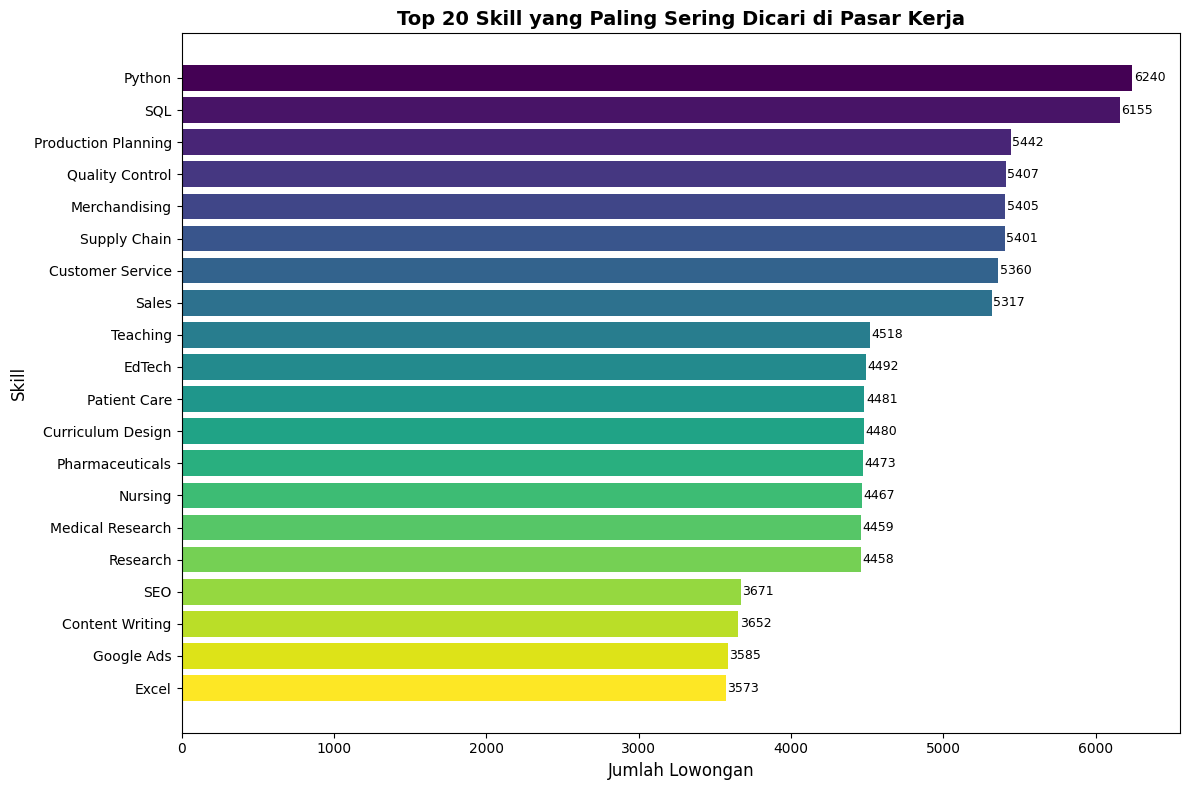

In [ ]:
# VISUALISASI 1: TOP SKILLS YANG PALING SERING DICARI

# Ekstrak semua skill dari kedua dataset
from collections import Counter

all_skills = []
for skills in all_jobs_df['skills_list'].dropna():
    all_skills.extend(skills)

# Hitung frekuensi skill
skill_counts = Counter(all_skills)
top_skills = dict(skill_counts.most_common(20))

# Visualisasi Top 20 Skills
plt.figure(figsize=(12, 8))
skills_names = list(top_skills.keys())
skills_values = list(top_skills.values())
colors = plt.cm.viridis(np.linspace(0, 1, len(skills_names)))

bars = plt.barh(skills_names, skills_values, color=colors)
plt.xlabel('Jumlah Lowongan', fontsize=12)
plt.ylabel('Skill', fontsize=12)
plt.title('Top 20 Skill yang Paling Sering Dicari di Pasar Kerja', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Tambahkan label nilai
for bar, val in zip(bars, skills_values):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)

plt.tight_layout()
plt.show()

#### Insight:
Visualisasi ini menampilkan 20 skill teratas yang paling banyak dicari di pasar kerja. Dapat dilihat bahwa skill seperti 'Python' dan 'SQL' memiliki permintaan yang sangat tinggi, menunjukkan dominasi kebutuhan akan keahlian teknis dan data.

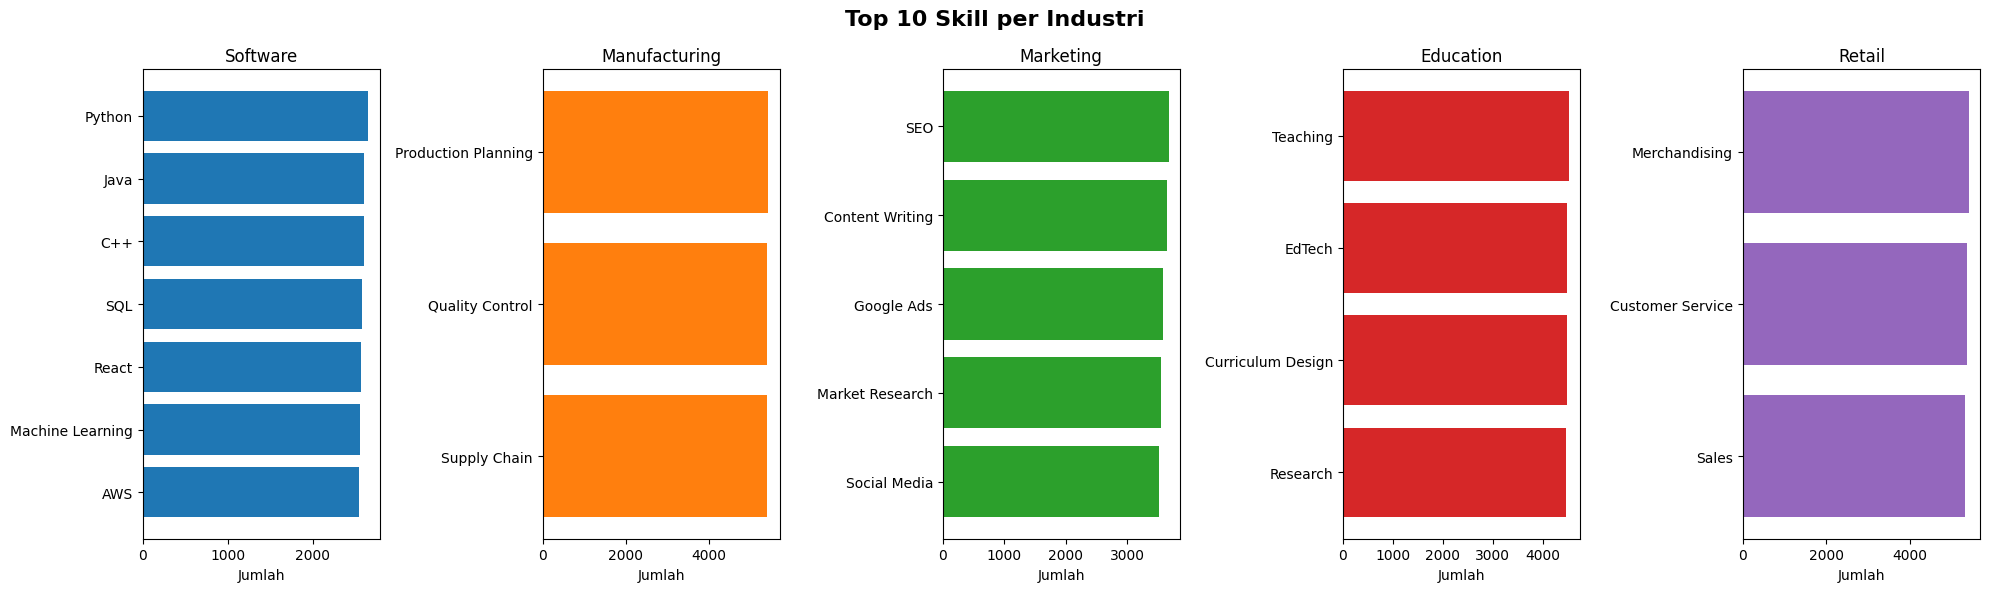

In [ ]:
# VISUALISASI 2: TOP SKILLS PER INDUSTRI
# Pilih top 5 industri
top_industries = all_jobs_df['category'].value_counts().head(5).index.tolist()

# Ekstrak skill per industri
industry_skills = {}
for industry in top_industries:
    industry_skills[industry] = []
    industry_data = all_jobs_df[all_jobs_df['category'] == industry]
    for skills in industry_data['skills_list'].dropna():
        industry_skills[industry].extend(skills)

    industry_skills[industry] = Counter(industry_skills[industry]).most_common(10)

# Visualisasi
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle('Top 10 Skill per Industri', fontsize=16, fontweight='bold')

for idx, (industry, skills) in enumerate(industry_skills.items()):
    if skills:
        skill_names = [s[0] for s in skills]
        skill_counts = [s[1] for s in skills]
        axes[idx].barh(skill_names, skill_counts, color=plt.cm.tab10(idx/10))
        axes[idx].set_title(industry, fontsize=12)
        axes[idx].invert_yaxis()
        axes[idx].set_xlabel('Jumlah')
    else:
        axes[idx].text(0.5, 0.5, 'No Data', ha='center', va='center')

plt.tight_layout()
plt.show()

#### Insight:
Grafik ini menunjukkan top 10 skill yang paling relevan untuk masing-masing dari 5 industri teratas. Setiap industri memiliki fokus skill yang berbeda, misalnya, 'Software' menuntut 'React', 'C++', sementara 'Retail' lebih fokus pada 'Merchandising' dan 'Customer Service'.

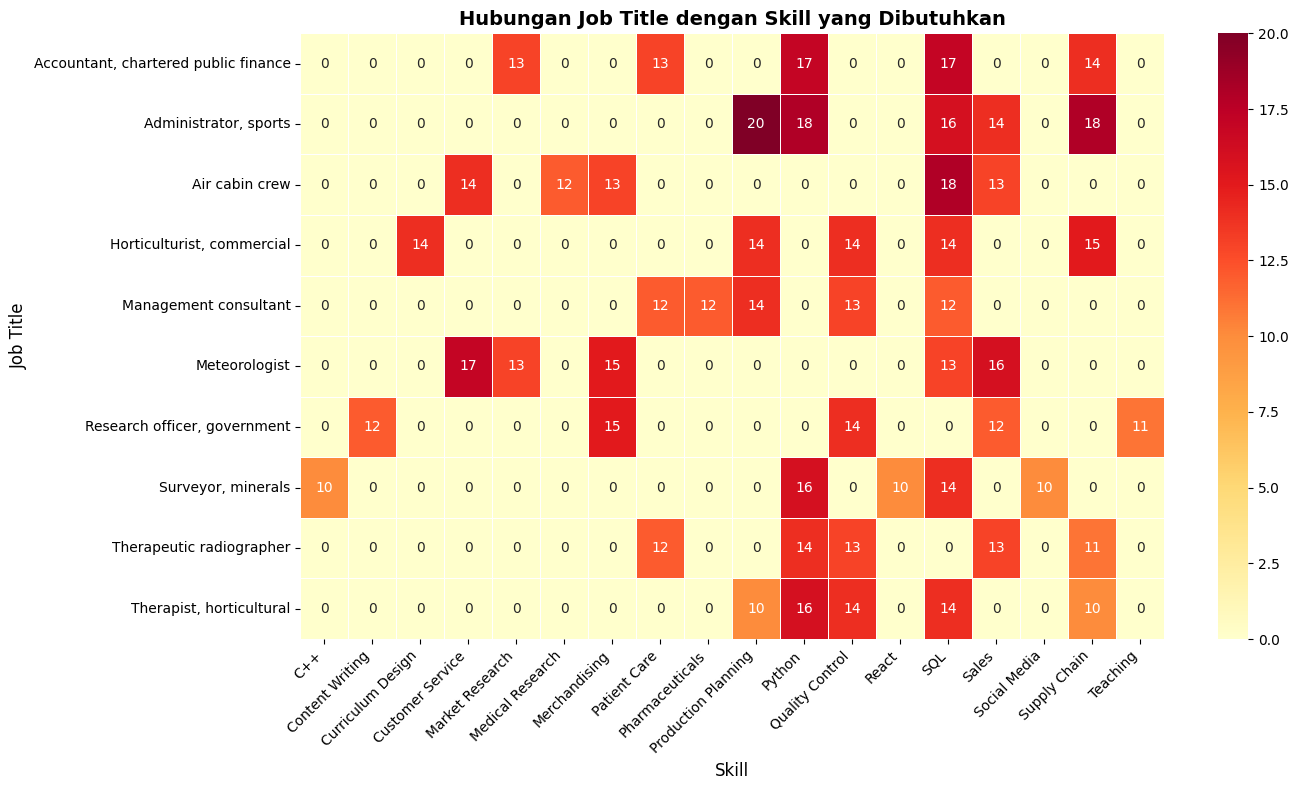

In [ ]:
# VISUALISASI 3: SKILLS PER POSISI PEKERJAAN (JOB TITLE)
# Pilih top 10 job title
top_jobs = all_jobs_df['job_title'].value_counts().head(10).index.tolist()

# Buat dataframe skill per job title
job_skill_data = []
for job in top_jobs:
    job_data = all_jobs_df[all_jobs_df['job_title'] == job]
    all_skills_job = []
    for skills in job_data['skills_list'].dropna():
        all_skills_job.extend(skills)
    skill_counter = Counter(all_skills_job)
    for skill, count in skill_counter.most_common(5):
        job_skill_data.append({
            'job_title': job,
            'skill': skill,
            'count': count
        })

job_skill_df = pd.DataFrame(job_skill_data)

# Visualisasi heatmap
pivot_table = job_skill_df.pivot(index='job_title', columns='skill', values='count').fillna(0)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Hubungan Job Title dengan Skill yang Dibutuhkan', fontsize=14, fontweight='bold')
plt.xlabel('Skill', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Insight:
Heatmap ini menggambarkan hubungan antara posisi pekerjaan (`job_title`) dan skill yang paling sering dibutuhkan untuk posisi tersebut. Misalnya, 'Administrator, sports' memiliki permintaan tinggi untuk 'Production Planning' dan 'Python', sementara 'Management consultant' membutuhkan 'Financial Modeling' dan 'SQL'.

### Pertanyaan 2: Bagaimana distribusi gaji berdasarkan industri?

Pada bagian ini, kita akan menjawab pertanyaan bisnis kedua: `Bagaimana distribusi gaji berdasarkan industri?` Ini akan melibatkan analisis rata-rata dan rentang gaji di berbagai sektor industri untuk mengidentifikasi industri dengan kompensasi tertinggi dan terendah.

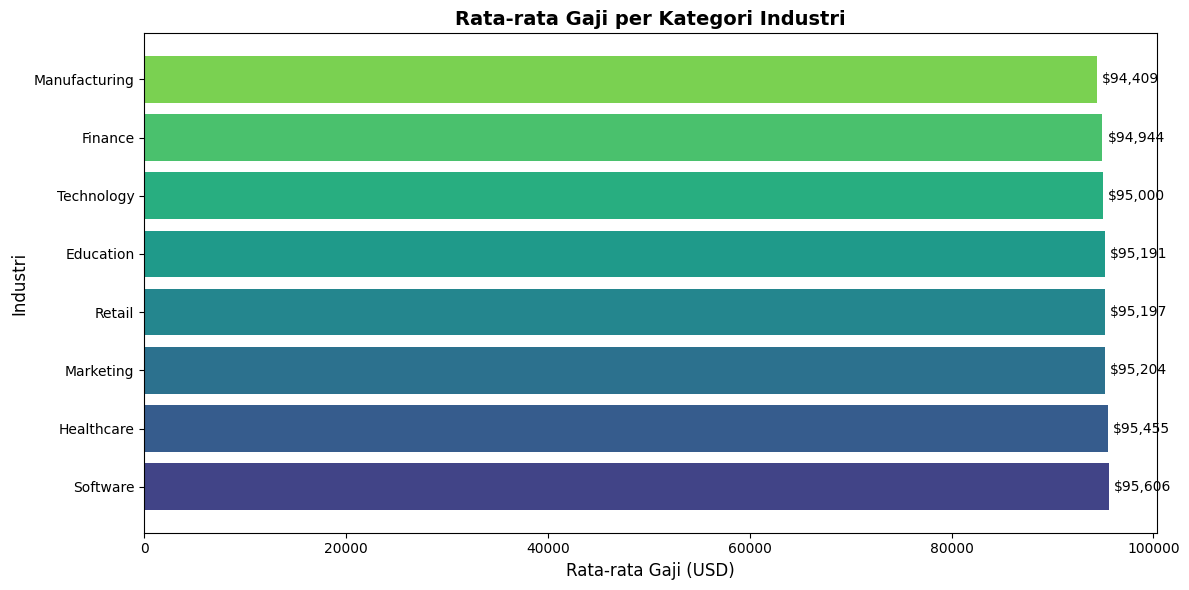

In [ ]:
# Rata-rata Gaji per Industri
avg_salary_by_industry = all_jobs_df.groupby('category')['salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(avg_salary_by_industry)))
bars = plt.barh(avg_salary_by_industry.index, avg_salary_by_industry.values, color=colors)
plt.title('Rata-rata Gaji per Kategori Industri', fontsize=14, fontweight='bold')
plt.xlabel('Rata-rata Gaji (USD)', fontsize=12)
plt.ylabel('Industri', fontsize=12)

for bar, val in zip(bars, avg_salary_by_industry.values):
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

#### Insight:
Visualisasi ini menampilkan rata-rata gaji per kategori industri. Industri 'Software' dan 'Healthcare' menonjol dengan rata-rata gaji yang lebih tinggi dibandingkan industri lain, menunjukkan sektor-sektor dengan potensi pendapatan yang lebih besar.

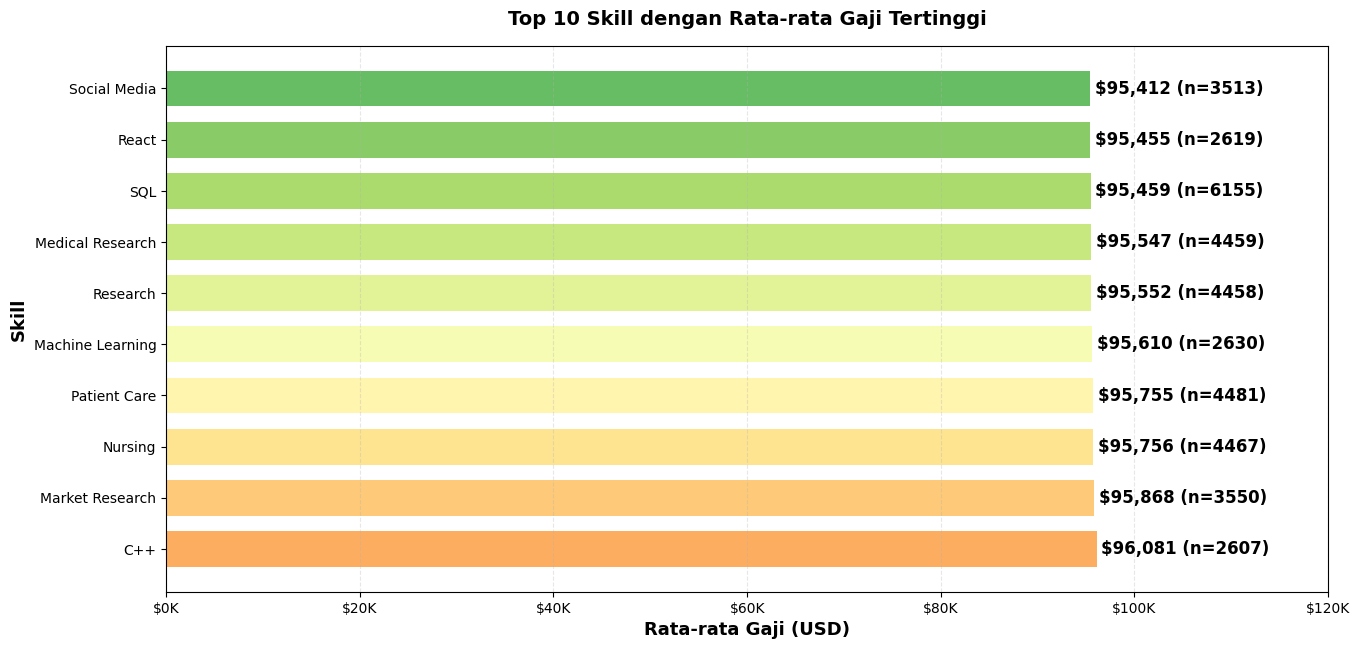

In [ ]:
# VISUALISASI TAMBAHAN 2: Top 10 Skill dengan Gaji Tertinggi
# Hitung rata-rata gaji per skill
skill_salary_data = []
for idx, row in all_jobs_df.iterrows():
    skills_list = row['skills_list']
    salary = row['salary']
    if isinstance(skills_list, list) and len(skills_list) > 0:
        for skill in skills_list:
            skill_salary_data.append({'skill': skill, 'salary': salary})

skill_salary_df = pd.DataFrame(skill_salary_data)
top_10_skills_by_salary = skill_salary_df.groupby('skill')['salary'].agg(['mean', 'count']).sort_values(by='mean', ascending=False).head(10)

# Filter hanya skill yang muncul minimal 50 kali (untuk akurasi)
top_10_skills_by_salary = top_10_skills_by_salary[top_10_skills_by_salary['count'] >= 50]

fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.8, len(top_10_skills_by_salary)))
bars = ax.barh(range(len(top_10_skills_by_salary)), top_10_skills_by_salary['mean'].values, color=colors, height=0.7)

ax.set_yticks(range(len(top_10_skills_by_salary)))
ax.set_yticklabels(top_10_skills_by_salary.index, fontsize=10)
ax.set_xlabel('Rata-rata Gaji (USD)', fontsize=13, fontweight='bold')
ax.set_ylabel('Skill', fontsize=13, fontweight='bold')
ax.set_title('Top 10 Skill dengan Rata-rata Gaji Tertinggi', fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
ax.set_xlim(0, 120000)

# Tambahkan label nilai dan jumlah kemunculan di sebelah kanan
for i, (val, count) in enumerate(zip(top_10_skills_by_salary['mean'].values, top_10_skills_by_salary['count'].values)):
    ax.text(val + 500, i, f'${val:,.0f} (n={int(count)})', va='center', fontsize=12, fontweight='bold')

plt.subplots_adjust(left=0.12, right=0.95, bottom=0.1)
plt.show()

#### Insight:
Visualisasi ini menunjukkan bahwa skill dengan gaji tertinggi bukan hanya skill teknis murni, melainkan kombinasi antara technical skills (C++, Machine Learning, SQL, React) dan domain-specific skills (Nursing, Patient Care, Medical Research, Market Research). Menariknya, terdapat supply-demand mismatch di mana SQL yang paling banyak dicari (n=6,155) justru memiliki gaji lebih rendah (usd 95,459) dibanding c++ yang jauh lebih sedikit dicari (n=2,607) namun bergaji tertinggi (usd 96,081) menunjukkan bahwa skill yang langka dan berkualitas bernilai premium di pasar kerja.

## Conclusion

- **Kesimpulan Pertanyaan 1: Skill apa saja yang paling sering dicari untuk posisi pekerjaan tertentu?**
  - **Secara keseluruhan**, skill 'Python' dan 'SQL' mendominasi permintaan di pasar kerja, diikuti oleh skill seperti 'Production Planning' dan 'Quality Control', menunjukkan tingginya kebutuhan akan keahlian teknis dan analitis.
  - **Berdasarkan Industri**, setiap industri memiliki prioritas skill yang berbeda. Misalnya, industri 'Software' sangat membutuhkan skill seperti 'React' dan 'C++', sedangkan industri 'Retail' lebih fokus pada 'Merchandising' dan 'Customer Service'.
  - **Berdasarkan Posisi Pekerjaan**, terdapat korelasi yang jelas antara judul pekerjaan dan skill yang dibutuhkan. Contohnya, 'Administrator, sports' sering membutuhkan 'Production Planning' dan 'Python', sementara 'Management consultant' banyak mencari skill 'Financial Modeling' dan 'SQL'.

- **Kesimpulan Pertanyaan 2: Bagaimana distribusi gaji berdasarkan industri?**
  - Analisis distribusi gaji menunjukkan bahwa industri 'Software' dan 'Healthcare' menawarkan rata-rata gaji yang paling tinggi dibandingkan industri lainnya. Hal ini mengindikasikan bahwa sektor-sektor ini adalah yang paling menjanjikan dari segi kompensasi.
  - Skill dengan gaji tertinggi (usd 95,412K - $96,081K) bukan hanya skill teknis murni, melainkan kombinasi antara technical skills (C++, Machine Learning, SQL, React) dan domain-specific skills (Nursing, Patient Care, Medical Research, Market Research).  untuk memaksimalkan kompensasi, career strategy tidak hanya fokus pada skill paling populer, melainkan mempertimbangkan **rarity value dan specialization** yang dikombinasikan dengan kemampuan teknis

### Kesimpulan Utama Berdasarkan Pertanyaan Bisnis (Actionable Insights)

Berdasarkan analisis data lowongan pekerjaan, terdapat beberapa tindakan strategis yang dapat diambil untuk meningkatkan peluang di pasar kerja. Pertama, penting untuk memprioritaskan pengembangan skill yang sesuai dengan permintaan pasar. Ini berarti menguasai skill dasar dan serbaguna seperti **Python** dan **SQL** yang sangat dicari di berbagai industri. Selain itu, setelah memiliki fondasi yang kuat, disarankan untuk melakukan riset mendalam dan mengembangkan skill spesifik yang paling dicari dalam industri atau posisi pekerjaan target, seperti 'React' atau 'C++' untuk industri *Software*, atau 'Merchandising' dan 'Customer Service' untuk *Retail*. Kedua, jika tujuan utama adalah kompensasi finansial yang lebih besar, sangat disarankan untuk mempertimbangkan karir di industri **Software** dan **Healthcare**, karena kedua sektor ini secara konsisten menawarkan rata-rata gaji tertinggi. Dengan menyelaraskan pengembangan skill dengan kebutuhan industri-industri ini, individu dapat memaksimalkan potensi pendapatan mereka.